# BG/NBD パラメータ推定 —  CDNOW データセット

Fader, Hardie & Lee（2005）の原論文で使用されたオンラインCDショップの購買データで、BG/NBDの検証には最もよく使われます。

**モデル**: BG/NBD (Beta-Geometric / Negative Binomial Distribution)
- 購入率 λ ~ Gamma(r, α) : 顧客ごとに異なる購入頻度
- 購入後の離脱確率 p ~ Beta(a, b) : 各購入後にチャーンする確率
- パラメータ: r, α, a, b を最尤法 (BFGS) で推定

In [21]:
using CSV, DataFrames, Optim, Distributions, SpecialFunctions, Random
using Plots, StatsPlots, Printf

In [22]:
# Plots 日本語フォント設定
ENV["GKS_ENCODING"] = "utf8"
gr(fontfamily="PlemolJP-Text")

default(
  fontfamily="PlemolJP-Text",
  guidefontsize=11,
  tickfontsize=8,
  legendfontsize=8,
  margin=5Plots.mm,
)

## 1. データ読み込み

In [23]:
df = CSV.read("bgnbd.csv",DataFrame) ; first(df,5)
describe(df)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,ID,1179.0,1,1179.0,2357,0,Int64
2,x,1.04243,0,0.0,29,0,Int64
3,t_x,6.84579,0.0,0.0,38.43,0,Float64
4,T,32.7158,27.0,32.71,38.86,0,Float64


In [24]:
x  = df.x
tx = df.t_x
T  = df.T

@printf("顧客数: %d\n", nrow(df))
@printf("X 平均: %.3f, 最大: %d\n", mean(x), maximum(x))
@printf("X=0 の割合: %.1f%%\n", 100*mean(x .== 0))
@printf("T の範囲: %d 〜 %d 日\n", minimum(T), maximum(T))

顧客数: 2357
X 平均: 1.042, 最大: 29
X=0 の割合: 59.9%
T の範囲: 27 〜 39 日


In [25]:
#DataFrame(:x => x, :tx => tx, :T => T)

## 2. 探索的分析

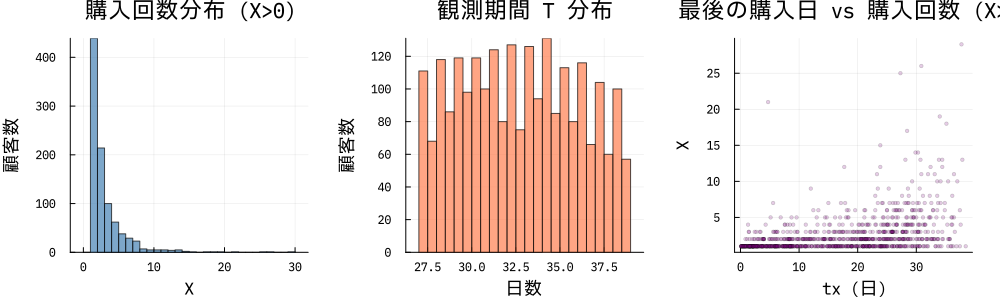

In [26]:
p1 = histogram(x[x .> 0]; bins=0:maximum(x[x.>0])+1,
    title="購入回数分布 (X>0)", xlabel="X", ylabel="顧客数",
    legend=false, color=:steelblue, alpha=0.7)

p2 = histogram(T; bins=30,
    title="観測期間 T 分布", xlabel="日数", ylabel="顧客数",
    legend=false, color=:coral, alpha=0.7)

p3 = scatter(tx[x.>0], x[x.>0];
    title="最後の購入日 vs 購入回数 (X>0)",
    xlabel="tx (日)", ylabel="X",
    legend=false, alpha=0.2, ms=2, color=:purple)

plot(p1, p2, p3; layout=(1,3), size=(1000, 300))

## 3. BG/NBD 対数尤度関数

個人 $i$ の尤度 (Fader, Hardie & Lee, 2005):

$$L_i = A_0 \left[1 + \delta_{x_i>0} \cdot \underbrace{\frac{a}{b+x_i-1} \cdot \left(\frac{\alpha+T_i}{\alpha+t_{x,i}}\right)^{r+x_i}}_{\delta_i}\right]$$

$$\ln A_0 = \ln\Gamma(r+x_i) - \ln\Gamma(r) + r\ln\alpha - (r+x_i)\ln(\alpha+T_i) + \ln B(a,\,b+x_i) - \ln B(a,\,b)$$

$$\ln L_i = \ln A_0 + \ln(1 + \delta_i) = \ln A_0 + \texttt{log1p\_exp}(\ln \delta_i) \qquad (x_i > 0)$$

$\ln \delta_i = \ln a - \ln(b+x_i-1) + (r+x_i)\ln\!\left(\dfrac{\alpha+T_i}{\alpha+t_{x,i}}\right)$

In [28]:
function log1p_exp_stable(x::Real)
    x > 35.0 && return x
    x < -35.0 && return exp(x)
    return log1p(exp(x))
end

"""
bgnbd_ll — 個人 i の BG/NBD 対数尤度  (Fader, Hardie & Lee, 2005)

ln L_i = ln A_0 + log1p_exp_stable(+ln_delta)   (x_i > 0)
ln L_i = ln A_0                                   (x_i = 0)

ln_delta = ln(a) - ln(b+x-1) + (r+x)*ln((α+T)/(α+tx))
"""
function bgnbd_ll(r::Real, alpha::Real, a::Real, b::Real,
                  xi::Integer, txi::Real, Ti::Real)

    ln_A0 = lgamma(r + xi) - lgamma(r) +
            r * log(alpha) - (r + xi) * log(alpha + Ti) +
            lgamma(a + b) + lgamma(b + xi) - lgamma(b) - lgamma(a + b + xi)

    xi == 0 && return ln_A0

    # δ = (a/(b+x-1)) * ((α+T)/(α+tx))^(r+x)
    # ln L = ln A0 + ln(1 + δ) = ln A0 + log1p_exp_stable(+ln_delta)
    ln_delta = log(a) - log(b + xi - 1) +
               (r + xi) * log((alpha + Ti) / (alpha + txi))

    return ln_A0 + log1p_exp_stable(ln_delta)   # 符号は + (修正済み)
end

function total_ll(r, alpha, a, b, x_vec, tx_vec, T_vec)
    ll = zero(promote_type(typeof(r), typeof(alpha), typeof(a), typeof(b)))
    @inbounds for i in eachindex(x_vec)
        ll += bgnbd_ll(r, alpha, a, b, x_vec[i], tx_vec[i], T_vec[i])
    end
    return ll
end

println("対数尤度関数を定義しました")

対数尤度関数を定義しました


## 4. 最尤推定 (BFGS)

パラメータを対数変換 $\theta_i = \ln p_i$ して正値制約を満たしながら最適化する。

In [29]:
function neg_ll(p_log)
    r_v     = exp(p_log[1])
    alpha_v = exp(p_log[2])
    a_v     = exp(p_log[3])
    b_v     = exp(p_log[4])
    v = -total_ll(r_v, alpha_v, a_v, b_v, x, tx, T)
    return isfinite(v) ? v : 1e15
end

# 初期値: r=1, alpha=10, a=1, b=5
p0 = log.([1.0, 10.0, 1.0, 5.0])

println("最適化を開始します (数分かかる場合があります)...")
result = optimize(neg_ll, p0, BFGS(),
    Optim.Options(show_trace=true, iterations=500))

println("収束: ", Optim.converged(result))
println("反復回数: ", Optim.iterations(result))

r_hat, alpha_hat, a_hat, b_hat = exp.(result.minimizer)

@printf("\n--- 推定結果 ---\n")
@printf("r     = %.4f  (購入率 Gamma 形状パラメータ)\n", r_hat)
@printf("alpha = %.4f  (購入率 Gamma スケールパラメータ)\n", alpha_hat)
@printf("a     = %.4f  (離脱確率 Beta 形状 a)\n", a_hat)
@printf("b     = %.4f  (離脱確率 Beta 形状 b)\n", b_hat)
@printf("\n平均購入率 = r/alpha = %.4f (1日あたり)\n", r_hat/alpha_hat)
@printf("購入後の平均存続確率 = b/(a+b) = %.4f\n", b_hat/(a_hat+b_hat))
@printf("対数尤度: %.2f\n", -result.minimum)

最適化を開始します (数分かかる場合があります)...
Iter     Function value   Gradient norm 
     0     1.032686e+04     1.688741e+03
 * time: 0.0
     1     1.028133e+04     8.668080e+02
 * time: 0.2609999179840088
     2     1.014099e+04     6.896907e+02
 * time: 0.3710000514984131
     3     1.013412e+04     6.910571e+02
 * time: 0.4240000247955322
     4     9.740212e+03     3.150587e+02
 * time: 0.4869999885559082
     5     9.634346e+03     1.817409e+02
 * time: 0.5309998989105225
     6     9.595501e+03     1.202139e+02
 * time: 0.5929999351501465
     7     9.583108e+03     9.707317e+00
 * time: 0.6439998149871826
     8     9.582471e+03     3.488811e+00
 * time: 0.6899998188018799
     9     9.582426e+03     6.273655e-01
 * time: 0.7359998226165771
    10     9.582426e+03     7.188877e-02
 * time: 0.7829999923706055
    11     9.582426e+03     7.098835e-03
 * time: 0.8359999656677246
    12     9.582426e+03     2.332917e-05
 * time: 0.8680000305175781
    13     9.582426e+03     9.003513e-06
 * time:

## 5. 推定パラメータの可視化

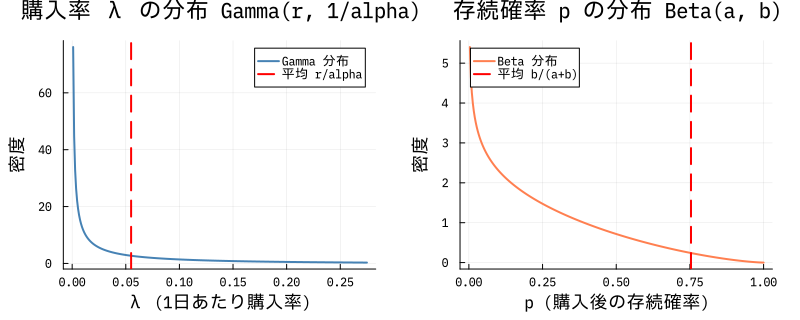

In [30]:
lam_grid = range(0, 5*r_hat/alpha_hat, length=300)
p_grid   = range(0, 1, length=300)

p4 = plot(lam_grid, pdf.(Gamma(r_hat, 1/alpha_hat), lam_grid);
    title="購入率 λ の分布 Gamma(r, 1/alpha)",
    xlabel="λ (1日あたり購入率)", ylabel="密度",
    legend=:topright, lw=2, color=:steelblue, label="Gamma 分布")
vline!([r_hat/alpha_hat]; lw=2, ls=:dash, color=:red, label="平均 r/alpha")

p5 = plot(p_grid, pdf.(Beta(a_hat, b_hat), p_grid);
    title="存続確率 p の分布 Beta(a, b)",
    xlabel="p (購入後の存続確率)", ylabel="密度",
    legend=:topleft, lw=2, color=:coral, label="Beta 分布")
vline!([b_hat/(a_hat+b_hat)]; lw=2, ls=:dash, color=:red, label="平均 b/(a+b)")

plot(p4, p5; layout=(1,2), size=(800, 320))

## 5b. ベイズ推定 (Turing.jl / NUTS)

事前分布:
- $r, a \sim \text{LogNormal}(0, 1)$
- $\alpha \sim \text{LogNormal}(2, 1)$ (スケール感: exp(2) ≈ 7)
- $b \sim \text{LogNormal}(1.5, 1)$ (スケール感: exp(1.5) ≈ 4.5)

CDNOW データは 2,357 件と小さいので全件使用する。

In [31]:
using Turing

# CDNOW は 2,357 件なので全件使用
x_sub  = x
tx_sub = tx
T_sub  = T

@printf("使用データ: %d 件 (X=0: %.1f%%)\n",
    length(x_sub), 100*mean(x_sub .== 0))

使用データ: 2357 件 (X=0: 59.9%)


In [32]:
@model function bgnbd_model(x_obs, tx_obs, T_obs)
    r     ~ LogNormal(0.0, 1.0)
    alpha ~ LogNormal(2.0, 1.0)
    a     ~ LogNormal(0.0, 1.0)
    b     ~ LogNormal(1.5, 1.0)

    ll = zero(r)
    for i in eachindex(x_obs)
        ll += bgnbd_ll(r, alpha, a, b, x_obs[i], tx_obs[i], T_obs[i])
    end
    Turing.@addlogprob! ll
end

model = bgnbd_model(x_sub, tx_sub, T_sub)
println("モデルを定義しました")

モデルを定義しました


In [33]:
# NUTS サンプリング (warmup 500 + 本番 1000 サンプル)
# MLE 推定値を初期値として使うと収束が速い
init_params = [r_hat, alpha_hat, a_hat, b_hat]

chain = sample(model, NUTS(500, 0.65), 1000;
    init_params = init_params,
    progress = false)

println(chain)

┌ Info: Found initial step size
│   ϵ = 0.025
└ @ Turing.Inference C:\Users\kimse\.julia\packages\Turing\RDk9I\src\mcmc\hmc.jl:226


MCMC chain (1000×18×1 Array{Float64, 3})


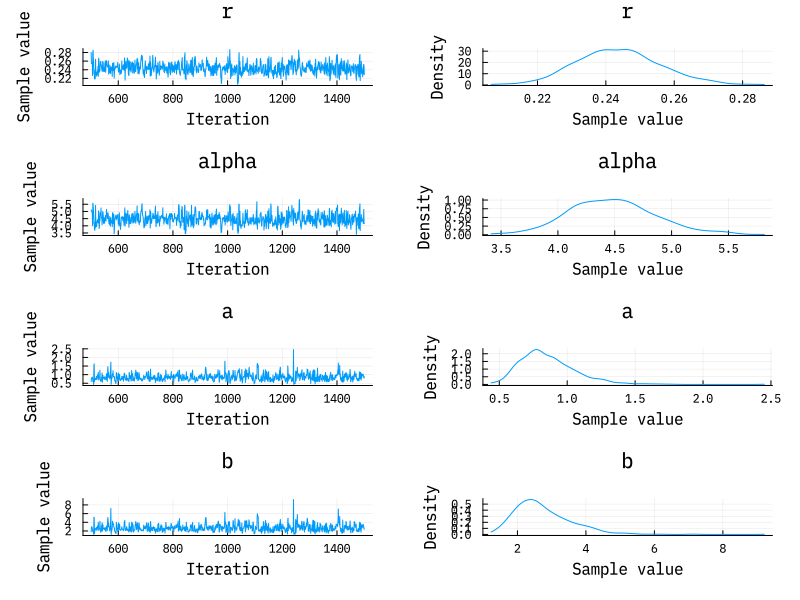

In [34]:
# トレースプロット + 事後分布
plot(chain; size=(800, 600))

In [35]:
# 事後統計量
r_post     = vec(chain[:r])
alpha_post = vec(chain[:alpha])
a_post     = vec(chain[:a])
b_post     = vec(chain[:b])

@printf("%-8s %8s %8s %8s %8s %8s %8s\n",
    "param", "MLE", "mean", "median", "std", "2.5%", "97.5%")
for (name, mle_v, post) in [
        ("r",     r_hat,     r_post),
        ("alpha", alpha_hat, alpha_post),
        ("a",     a_hat,     a_post),
        ("b",     b_hat,     b_post)]
    q = quantile(post, [0.025, 0.975])
    @printf("%-8s %8.4f %8.4f %8.4f %8.4f %8.4f %8.4f\n",
        name, mle_v, mean(post), median(post), std(post), q[1], q[2])
end

param         MLE     mean   median      std     2.5%    97.5%
r          0.2426   0.2437   0.2435   0.0125   0.2206   0.2693
alpha      4.4135   4.4803   4.4698   0.3868   3.7691   5.3495
a          0.7929   0.8584   0.8232   0.2093   0.5515   1.3251
b          2.4258   2.7417   2.5710   0.8430   1.5250   4.5698


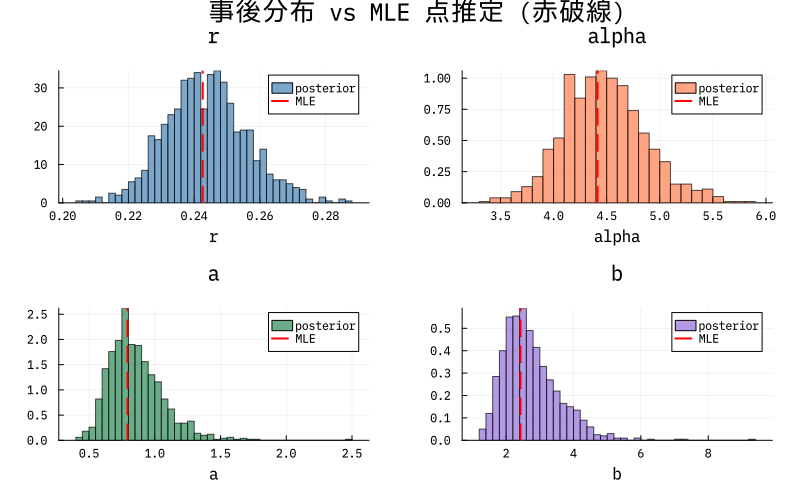

In [36]:
# 事後分布のヒストグラム (MLE 点推定と比較)
ph1 = histogram(r_post;     title="r",     xlabel="r",     bins=40,
    legend=:topright, label="posterior", color=:steelblue, alpha=0.7,
    normalize=:pdf)
vline!([r_hat]; lw=2, ls=:dash, color=:red, label="MLE")

ph2 = histogram(alpha_post; title="alpha", xlabel="alpha", bins=40,
    legend=:topright, label="posterior", color=:coral, alpha=0.7,
    normalize=:pdf)
vline!([alpha_hat]; lw=2, ls=:dash, color=:red, label="MLE")

ph3 = histogram(a_post;     title="a",     xlabel="a",     bins=40,
    legend=:topright, label="posterior", color=:seagreen, alpha=0.7,
    normalize=:pdf)
vline!([a_hat]; lw=2, ls=:dash, color=:red, label="MLE")

ph4 = histogram(b_post;     title="b",     xlabel="b",     bins=40,
    legend=:topright, label="posterior", color=:mediumpurple, alpha=0.7,
    normalize=:pdf)
vline!([b_hat]; lw=2, ls=:dash, color=:red, label="MLE")

plot(ph1, ph2, ph3, ph4; layout=(2,2), size=(800, 500),
    suptitle="事後分布 vs MLE 点推定 (赤破線)")

## 6. P(alive | データ) の計算

$$P(\text{alive} \mid x_i, t_{x,i}, T_i) = \frac{1}{1 + \delta_{x_i>0} \cdot \frac{a}{b+x_i-1} \cdot \left(\frac{\alpha+T_i}{\alpha+t_{x,i}}\right)^{r+x_i}}$$

$x_i = 0$ の顧客は購入後チャーンの機会がないため $P(\text{alive}) = 1$。

P(alive) の要約
  平均:           0.813
  中央値:         1.000
  P(alive)>0.8:   64.7%
  P(alive)<0.2:   3.6%


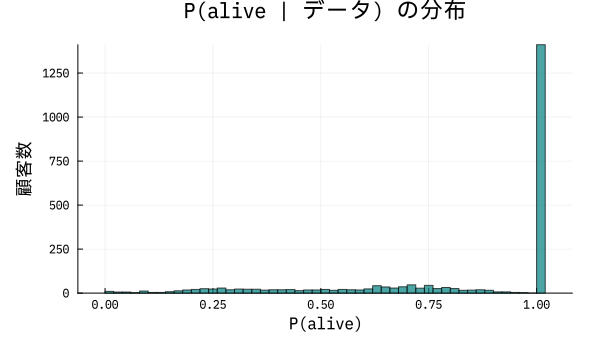

In [37]:
function p_alive_bgnbd(r, alpha, a, b, xi, txi, Ti)
    xi == 0 && return 1.0
    ln_delta = log(a) - log(b + xi - 1) +
               (r + xi) * log((alpha + Ti) / (alpha + txi))
    return 1.0 / (1.0 + exp(ln_delta))
end

pa = [p_alive_bgnbd(r_hat, alpha_hat, a_hat, b_hat, x[i], tx[i], T[i])
      for i in eachindex(x)]

@printf("P(alive) の要約\n")
@printf("  平均:           %.3f\n", mean(pa))
@printf("  中央値:         %.3f\n", median(pa))
@printf("  P(alive)>0.8:   %.1f%%\n", 100*mean(pa .> 0.8))
@printf("  P(alive)<0.2:   %.1f%%\n", 100*mean(pa .< 0.2))

histogram(pa; bins=50,
    title="P(alive | データ) の分布",
    xlabel="P(alive)", ylabel="顧客数",
    legend=false, color=:teal, alpha=0.7, size=(600, 350))

## 7. モンテカルロ検証 (観測 vs シミュレーション)

推定パラメータを使ってデータを再生成し、観測された購入回数分布と比較することでモデルの適合度を確認する。

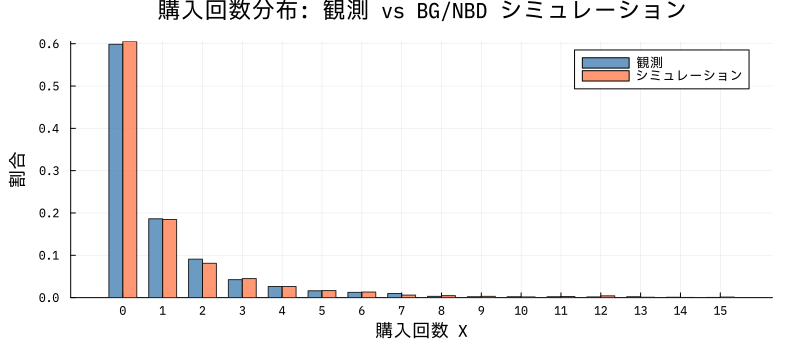

In [38]:
function simulate_bgnbd(r, alpha, a, b, T_obs; n_sim=50_000)
    rng = MersenneTwister(42)
    T_vec = isa(T_obs, AbstractVector) ? T_obs : fill(Float64(T_obs), n_sim)
    n = min(n_sim, length(T_vec))
    sim_x = zeros(Int, n)
    for i in 1:n
        lam_i = rand(rng, Gamma(r, 1/alpha))
        # p_i ~ Beta(a,b) は「購入後の死亡確率」(E[p]=a/(a+b))
        p_i   = rand(rng, Beta(a, b))
        t = 0.0; cnt = 0
        while true
            dt = -log(rand(rng)) / lam_i   # 次の購入までの待ち時間
            t += dt
            t > T_vec[i] && break
            cnt += 1
            rand(rng) < p_i && break        # 購入後に死亡確率 p_i で離脱 (修正済み)
        end
        sim_x[i] = cnt
    end
    return sim_x
end

sim_x = simulate_bgnbd(r_hat, alpha_hat, a_hat, b_hat, T;
    n_sim=min(length(T), 100_000))

max_x_plot = 15
obs_freq = [mean(x .== k) for k in 0:max_x_plot]
sim_freq = [mean(sim_x .== k) for k in 0:max_x_plot]

groupedbar(
    hcat(obs_freq, sim_freq);
    bar_position=:dodge, bar_width=0.7,
    xticks=(1:max_x_plot+1, string.(0:max_x_plot)),
    xlabel="購入回数 X", ylabel="割合",
    label=["観測" "シミュレーション"],
    title="購入回数分布: 観測 vs BG/NBD シミュレーション",
    color=[:steelblue :coral], alpha=0.8, size=(800, 350)
)

## 8. 将来 30 週間の期待購買数

CDNOW データの時間単位は**週**。`T` の範囲 27〜39 は週数。

個人レベルで Gamma 事後分布を更新した購入率（週あたり）を使い、将来の期待購買数を計算する。

$$E[\text{future}_i \mid \text{data}] = P(\text{alive}_i) \times \frac{r + x_i}{\alpha + T_i} \times 30 \text{（週）}$$

In [ ]:
# 事後平均購入率: (r + x_i) / (alpha + T_i)  [Gamma 共役更新、単位: 週あたり]
lam_post = (r_hat .+ x) ./ (alpha_hat .+ T)

# 今後 30 週間の期待購買数
E_future30 = pa .* lam_post .* 30.0

@printf("将来 30 週間 期待購買数の要約\n")
@printf("  全体平均:       %.3f\n", mean(E_future30))
@printf("  中央値:         %.3f\n", median(E_future30))
@printf("  >5 回予測の顧客: %.1f%%\n", 100*mean(E_future30 .> 5))

top20_idx = sortperm(E_future30; rev=true)[1:20]
top20 = DataFrame(
    ID         = df.ID[top20_idx],
    X          = x[top20_idx],
    T_weeks    = T[top20_idx],
    P_alive    = round.(pa[top20_idx],       digits=3),
    lam_week   = round.(lam_post[top20_idx], digits=4),
    E_future30 = round.(E_future30[top20_idx], digits=2)
)
println("\n将来 30 週間 購買期待数 Top 20")
display(top20)

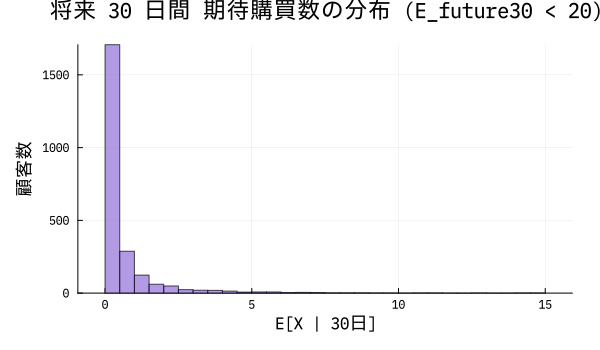

In [41]:
histogram(E_future30[E_future30 .< 20]; bins=50,
    title="将来 30 日間 期待購買数の分布 (E_future30 < 20)",
    xlabel="E[X | 30日]", ylabel="顧客数",
    legend=false, color=:mediumpurple, alpha=0.7, size=(600, 350))

## 9. まとめ

In [42]:
println("=== BG/NBD 推定結果まとめ ===")
println("データ: CDNOW データセット (bgnbd.csv)")
println("原論文: Fader, Hardie & Lee (2005)")
@printf("顧客数: %d\n\n", nrow(df))
println("【推定パラメータ】")
@printf("  r     = %.4f  (購入率 Gamma 形状)\n", r_hat)
@printf("  alpha = %.4f  (購入率 Gamma スケール)\n", alpha_hat)
@printf("  a     = %.4f  (離脱確率 Beta 形状 a)\n", a_hat)
@printf("  b     = %.4f  (離脱確率 Beta 形状 b)\n", b_hat)
println()
println("【論文掲載値との比較 (Fader et al. 2005, Table 2)】")
println("  r=0.2426, alpha=4.4137, a=0.7930, b=2.4259")
println()
println("【解釈】")
@printf("  平均購入率:             %.4f 回/週 = %.2f 回/月\n",
    r_hat/alpha_hat, r_hat/alpha_hat*4)
@printf("  購入後の平均死亡確率:   %.1f%%\n", 100*a_hat/(a_hat+b_hat))
@printf("  P(alive) 平均:          %.3f\n", mean(pa))
@printf("  将来 30 日間 期待購買数 (全顧客平均): %.3f\n", mean(E_future30))

=== BG/NBD 推定結果まとめ ===
データ: CDNOW データセット (bgnbd.csv)
原論文: Fader, Hardie & Lee (2005)
顧客数: 2357

【推定パラメータ】
  r     = 0.2426  (購入率 Gamma 形状)
  alpha = 4.4135  (購入率 Gamma スケール)
  a     = 0.7929  (離脱確率 Beta 形状 a)
  b     = 2.4258  (離脱確率 Beta 形状 b)

【論文掲載値との比較 (Fader et al. 2005, Table 2)】
  r=0.2426, alpha=4.4137, a=0.7930, b=2.4259

【解釈】
  平均購入率:             0.0550 回/週 = 0.22 回/月
  購入後の平均死亡確率:   24.6%
  P(alive) 平均:          0.813
  将来 30 日間 期待購買数 (全顧客平均): 0.668
